# <b>Sales Forecasting Project - Prophet</b>

##  Objectives 

This project aims to develop a **Sales Forecasting System** powered by data analysis and machine learning techniques, in order to achieve the following objectives:

* **Analyze historical data** related to sales, customers, and discounts to uncover hidden patterns and relationships.
* **Support managerial decision-making** by providing insights that help anticipate demand, manage inventory, and optimize pricing strategies.
* **Address influencing factors** such as discounts, seasonality, and different sales periods (monthly, quarterly, yearly).
* **Build a Real-Time Forecasting Model** that can accurately predict future sales.
* **Improve operational efficiency** and reduce risks associated with inaccurate sales estimations.


# Section 1: Import Libraries
----------- ------------
##### Add any other libraries you need (XGBoost, Prophet, LightGBM, etc.)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.diagnostics import cross_validation, performance_metrics
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
import joblib

# Section 2: Load Dataset
----------- ------------

In [ ]:
# 1. Load the dataset
file_path = "car_sales_2018_2024.csv"
df_dirty = pd.read_csv(file_path)

# Make a copy to work on
df = df_dirty.copy()

## Total Sales Forecast using Prophet

In [ ]:
prophet_df = pd.read_csv("car_sales_2018_2024_prophet_df.csv")

In [502]:
prophet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sale Year         78 non-null     int64  
 1   Sale Month Num    78 non-null     int64  
 2   Total_Sales       78 non-null     float64
 3   Date              78 non-null     object 
 4   Sales_t-1         78 non-null     float64
 5   Sales_t-2         78 non-null     float64
 6   Sales_t-3         78 non-null     float64
 7   Rolling_3M        78 non-null     float64
 8   Rolling_6M        78 non-null     float64
 9   Next_Month_Sales  78 non-null     float64
 10  Season            78 non-null     object 
 11  Cumulative_Sales  78 non-null     float64
 12  Sale Quarter      78 non-null     int64  
dtypes: float64(8), int64(3), object(2)
memory usage: 8.1+ KB


In [ ]:
# Rename columns for Prophet
prophet_df.rename(columns={"Date": "ds", "Total_Sales": "y"}, inplace=True)

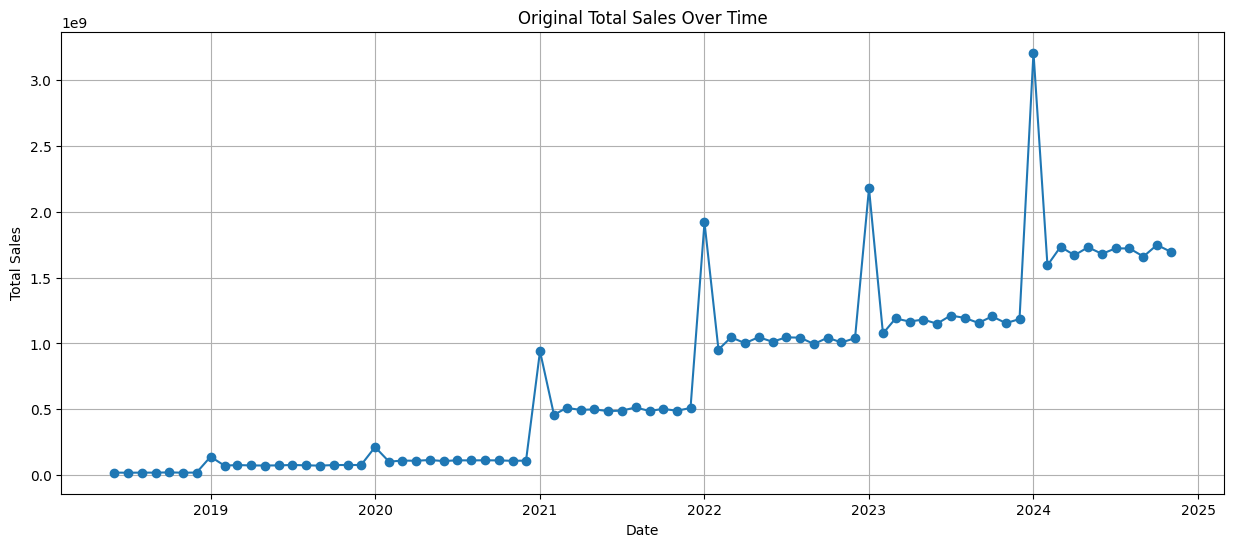

In [ ]:
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

plt.rcParams["agg.path.chunksize"] = 20000

plt.figure(figsize=(15, 6))
plt.plot(prophet_df["ds"], prophet_df["y"], marker="o", linestyle="-")
plt.title("Original Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

In [ ]:
prophet_df["y"] = np.log(prophet_df["y"])

In [ ]:
# Convert 'Season' to dummy variables for categorical regressors
season_dummies = pd.get_dummies(prophet_df["Season"], prefix="Season")
prophet_df = pd.concat([prophet_df, season_dummies], axis=1)
prophet_df.drop(columns=["Season"], inplace=True)

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    prophet_df[
        ["Sales_t-1", "Sales_t-3", "Rolling_3M", "Rolling_6M", "Cumulative_Sales"]
    ]
)
scaled_df = pd.DataFrame(
    scaled_features,
    columns=["Sales_t-1", "Sales_t-3", "Rolling_3M", "Rolling_6M", "Cumulative_Sales"],
)

In [ ]:
# Define the regressors to include in the model
regressors = ["Sales_t-1", "Rolling_3M", "Sale Quarter"] + list(season_dummies.columns)

In [ ]:
# Create the Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    growth="linear",
    interval_width=0.9,
)

In [401]:
# Add all extra regressors
for reg in regressors:
    model.add_regressor(reg)

In [506]:
# Fit the model on the prepared data
model.fit(prophet_df)

00:10:04 - cmdstanpy - INFO - Chain [1] start processing
00:10:04 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
df_cv = cross_validation(
    model, initial="1095 days", period="365 days", horizon="365 days"
)

df_p = performance_metrics(df_cv)
print(df_p.head())

  0%|          | 0/3 [00:00<?, ?it/s]

00:10:06 - cmdstanpy - INFO - Chain [1] start processing
00:10:06 - cmdstanpy - INFO - Chain [1] done processing
00:10:06 - cmdstanpy - INFO - Chain [1] start processing
00:10:06 - cmdstanpy - INFO - Chain [1] done processing
00:10:07 - cmdstanpy - INFO - Chain [1] start processing
00:10:07 - cmdstanpy - INFO - Chain [1] done processing


   horizon           mse          rmse           mae      mape     mdape  \
0  29 days  1.096862e+16  1.047312e+08  8.356630e+07  0.083764  0.059930   
1  60 days  9.051887e+17  9.514140e+08  8.861846e+08  0.359333  0.412907   
2  91 days  5.430715e+16  2.330390e+08  2.141655e+08  0.201792  0.198492   
3 119 days  9.199605e+16  3.033085e+08  2.929917e+08  0.266956  0.263683   
4 120 days  1.090364e+17  3.302066e+08  3.298355e+08  0.262097  0.263683   

      smape  coverage  
0  0.079555  1.000000  
1  0.446707  0.000000  
2  0.220175  0.333333  
3  0.285371  0.111111  
4  0.280829  0.000000  


In [ ]:
# Create future DataFrame for next 12 months
future = model.make_future_dataframe(periods=12, freq="MS")  # MS = Month Start

In [361]:
# Add the same regressors columns
for reg in regressors:
    if reg in prophet_df.columns:
        future[reg] = prophet_df[reg].iloc[-1]

In [509]:
# Make predictions
forecast = model.predict(future)

In [ ]:
# Display predictions for the last 12 months
# forecast['yhat'] = np.exp(forecast['yhat'])
# forecast['yhat_lower'] = np.exp(forecast['yhat_lower'])
# forecast['yhat_upper'] = np.exp(forecast['yhat_upper'])
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(12)

,ds,yhat,yhat_lower,yhat_upper
78,2024-12-01,1.866606e+09,1.589584e+09,2.165825e+09
79,2025-01-01,2.510949e+09,2.225578e+09,2.761652e+09
80,2025-02-01,2.101248e+09,1.811013e+09,2.380617e+09
81,2025-03-01,2.104455e+09,1.834172e+09,2.382569e+09
82,2025-04-01,1.938775e+09,1.646900e+09,2.204500e+09
83,2025-05-01,2.068611e+09,1.773517e+09,2.348811e+09
84,2025-06-01,2.092900e+09,1.805780e+09,2.381283e+09
85,2025-07-01,1.997556e+09,1.707889e+09,2.279948e+09
86,2025-08-01,2.078196e+09,1.791748e+09,2.360984e+09
87,2025-09-01,2.181903e+09,1.885700e+09,2.448378e+09


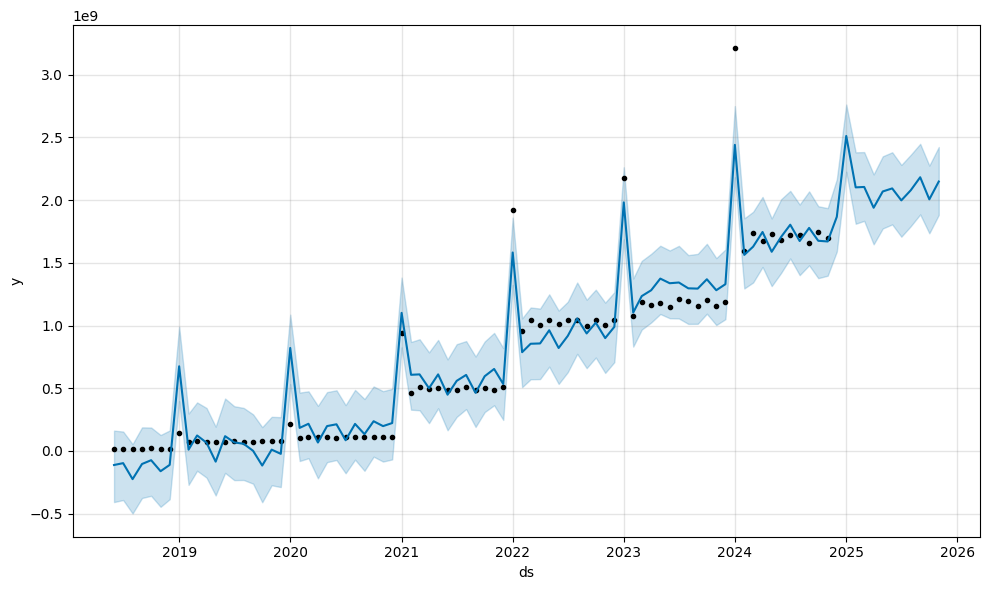

In [511]:
# Plot the forecast
model.plot(forecast)
plt.show()

### Key Insights from the Predictions

#### 1. Strong and Consistent Growth
The forecasts show that the **general sales trend is upward and stable**. This means the dealership can expect revenue to continue growing in the coming years. This is a very positive indicator that justifies planning for increased investment and business expansion in the long term.

#### 2. Clear Seasonal Peak
The most obvious pattern in the data is the **huge jump in sales at the beginning of each year** (especially in January). This pattern repeats consistently. The model predicts that this peak will strongly repeat in early 2025.

#### 3. Planning for Uncertainty
The predictions are not a single number, but a **specific range** (the shaded blue area in the chart). This range shows the probabilities of sales.
* The **lower bound of the forecast** (the bottom line) represents the **safest sales target** that the dealership should achieve at a minimum.
* The **upper bound of the forecast** (the top line) represents the **best possible scenario** that the dealership should be prepared for.

---

### Actionable Recommendations

Based on these insights, the dealership can make the following decisions:

* **For Seasonality:**
    * **Inventory Preparation:** Before the end of the year, the dealership should ensure it has sufficient inventory of the most in-demand cars to meet the huge sales increase expected in January.
    * **Early Marketing Campaigns:** Launch special "New Year Offers" promotions in December to motivate potential customers before the peak arrives.
    * **Operational Readiness:** Increase the number of the sales team and train them well to handle the large influx of customers during that period.

* **For Growth:**
    * **Strategic Planning:** The dealership can use these forecasts as a tool for financial planning and setting more realistic quarterly and annual sales goals.

These predictions provide the dealership with a very clear roadmap of what to expect, allowing it to shift from being reactive to **proactive planning**.

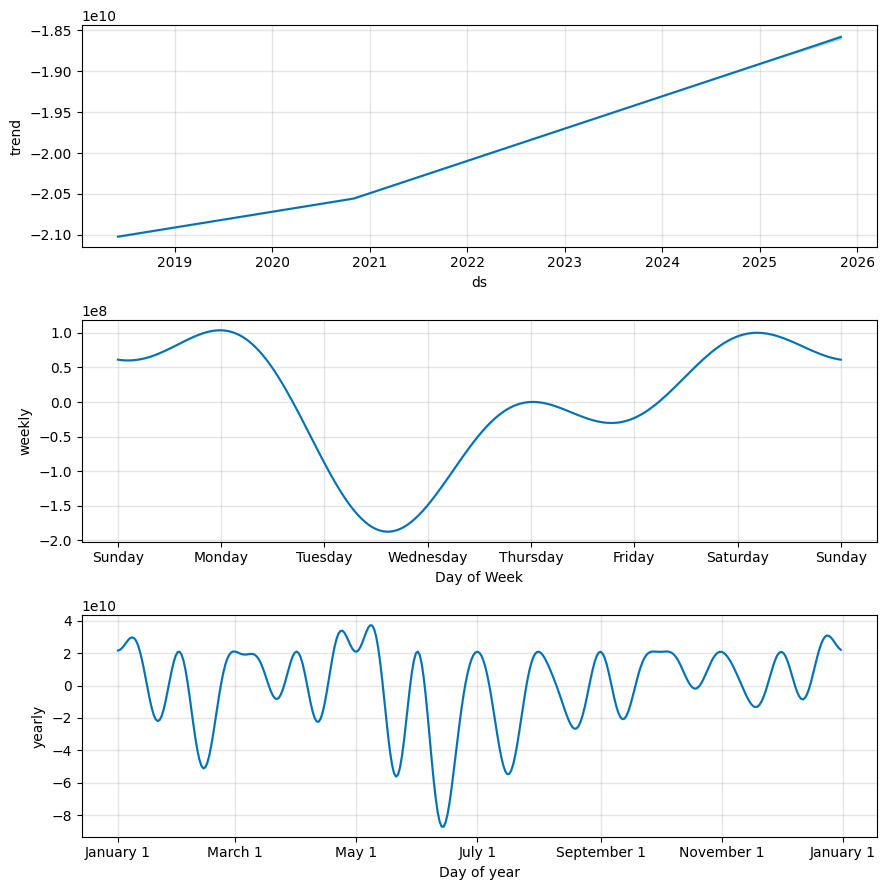

In [445]:
fig2 = model.plot_components(forecast)
plt.show()

### Monthly Sales Forecast Analysis
Based on the generated Prophet plots, we can derive key insights about the upcoming month's sales and the role of seasonality:

#### Trend Analysis 

The top plot shows a clear increasing trend in the overall sales over time. This indicates that the model expects the baseline sales (the sales after removing seasonal effects) to continue growing in the future.

#### Seasonality Analysis 

The bottom plot reveals the average yearly seasonal pattern. We can observe a significant peak around March and a trough around May. While there are smaller fluctuations throughout the year, the general pattern shows that certain months perform better than others. The plot indicates a slight dip in sales around October.

#### Forecasting the Next Month (Assuming it's October) 

 The forecast for the next month (October) will be a combination of two opposing forces: 

* <b> The positive trend:</b> The overall upward trend in sales will contribute to a higher sales forecast.

* <b> The negative seasonal effect: </b> The average historical performance of October suggests a slight decrease in sales compared to the previous month.

The final forecast for October (the next month) is like a tug-of-war between these two effects. While our long-term sales are headed up, the usual short-term pattern for October might cause a small dip before sales pick up again in the following months.

--------------------------

### Recommendations for October
Based on our sales analysis, which shows a positive long-term trend but a potential slight seasonal dip in October, here's what the car dealership should do next month.

- <b> Proactive Sales Campaigns</b>

Launch early promotions to generate sales before the typical seasonal dip begins.

- <b> Focus on Existing Customers</b>

Offer exclusive service deals or upgrade incentives to current customers to generate additional revenue.

- <b> Strategic Inventory Management</b>

Avoid ordering large quantities of new cars and concentrate on selling the current inventory.

- <b> Enhance Digital Marketing</b>

Use targeted online ads to capture a high-intent audience and drive cost-effective sales.

- <b> Prepare the Sales Team</b>

Equip the team with incentives and negotiation skills to help them meet sales targets during this period.

<b>In short, </b> October is a month for strategic planning and caution, not for significant growth. The goal is to minimize the seasonal dip and maintain a steady sales pace.